<a href="https://colab.research.google.com/github/SathyaPrakashD/Classical-ML-Pipeline/blob/main/fetch_olivetti_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import fetch_olivetti_faces
import pandas as pd

# Step 1 — Load the dataset
import pandas as pd


# Step 1 — Load the dataset
data = fetch_olivetti_faces()
#print(data.feature_names)
# Step 2 — Wrap features into a DataFrame
# Hint: data.feature_names gives you column names
df = pd.DataFrame(data.data)



# Step 3 — Add the target column
df['target'] = data.target

#print(df.head(5))


# Step 4 — Print basic info
print("Shape:", df.shape)          # how many rows and columns?
print("Number of unique individuals (targets):", len(pd.Series(data.target).unique()))
print("Target values range from:", min(data.target), "to", max(data.target))
print("Class counts:\n", df['target'].value_counts())

# Step 5 — Preview first 5 rows
#print(df.___)jacob

Shape: (400, 4097)
Number of unique individuals (targets): 40
Target values range from: 0 to 39
Class counts:
 target
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
Name: count, dtype: int64


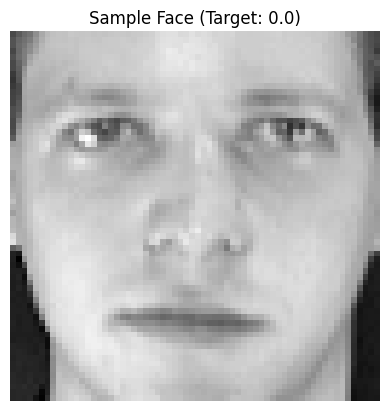

In [40]:
import matplotlib.pyplot as plt

# Select the first image (row 0) from the DataFrame
sample_image_pixels = df.iloc[0, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[0]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

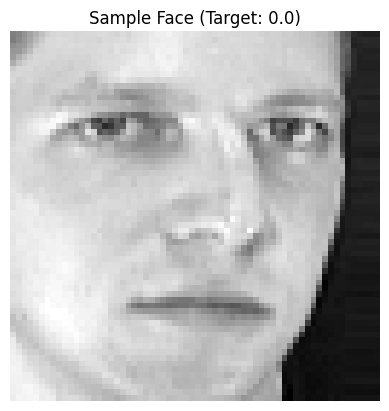

In [41]:
import matplotlib.pyplot as plt

# Select the first image (row 1) from the DataFrame
sample_image_pixels = df.iloc[1, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[1]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

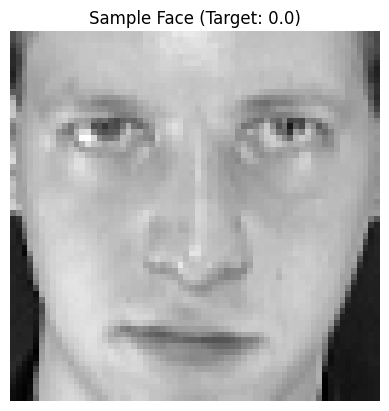

In [42]:
import matplotlib.pyplot as plt

# Select the first image (row 2) from the DataFrame
sample_image_pixels = df.iloc[2, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[2]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

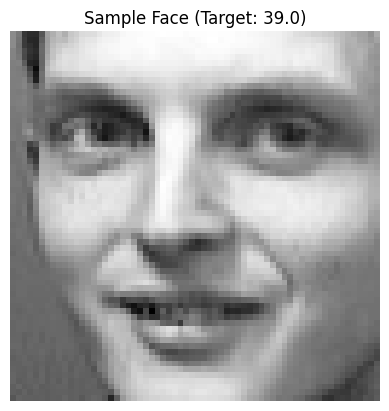

In [43]:
import matplotlib.pyplot as plt

# Select the first image (row 399) from the DataFrame
sample_image_pixels = df.iloc[399, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[399]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

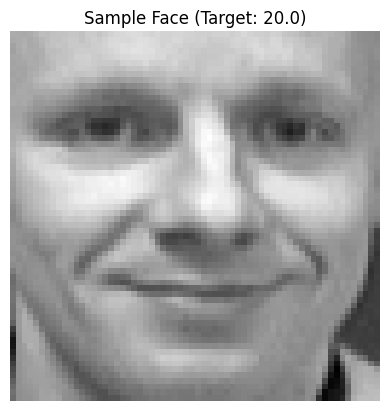

In [44]:
import matplotlib.pyplot as plt

# Select the first image (row 200) from the DataFrame
sample_image_pixels = df.iloc[200, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[200]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

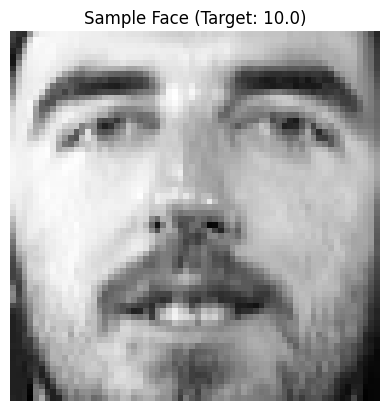

In [45]:
import matplotlib.pyplot as plt

# Select the first image (row 100) from the DataFrame
sample_image_pixels = df.iloc[100, :-1].values  # Exclude the 'target' column

# The Olivetti faces are 64x64 pixels
image_shape = (64, 64)

# Reshape the 1D array of pixels into a 2D image
sample_image = sample_image_pixels.reshape(image_shape)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Face (Target: {df.iloc[100]['target']})")
plt.axis('off') # Hide axes for better visualization
plt.show()

In [46]:
# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

print(X.shape)
print(y.shape)

(400, 4096)
(400,)


In [47]:

# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)



# Step 5 — Verify scaling worked
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\nBefore scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())
#print(X_train_df[['alcohol', 'magnesium', 'proline']].describe().round(2))

Train size: 320
Test size: 80

Before scaling (train set):
         0         1         2         3         4         5         6     \
3    0.198347  0.194215  0.194215  0.194215  0.190083  0.190083  0.243802   
18   0.681818  0.706612  0.719008  0.710744  0.714876  0.727273  0.735537   
202  0.322314  0.409091  0.454545  0.471074  0.483471  0.471074  0.516529   
250  0.615702  0.685950  0.714876  0.739669  0.735537  0.752066  0.752066   
274  0.652893  0.665289  0.673554  0.719008  0.752066  0.764463  0.739669   

         7         8         9     ...      4086      4087      4088  \
3    0.404959  0.483471  0.516529  ...  0.652893  0.636364  0.657025   
18   0.739669  0.735537  0.727273  ...  0.260331  0.103306  0.111570   
202  0.541322  0.545455  0.549587  ...  0.429752  0.429752  0.450413   
250  0.739669  0.760331  0.780992  ...  0.223140  0.247934  0.272727   
274  0.776860  0.785124  0.772727  ...  0.157025  0.148760  0.169421   

         4089      4090      4091      4092  

In [48]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=1000)   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 0.975

First test sample — true label   : 20
First test sample — predicted    : 20
First test sample — probabilities: [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.997 0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.   ]


In [49]:

# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X, y, cv=5)

# Fit the pipeline on the full dataset for subsequent use outside of cross_val_score
pipeline.fit(X, y)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [1.     0.95   0.975  0.975  0.9375]
Mean accuracy: 0.9675
Std deviation: 0.0218


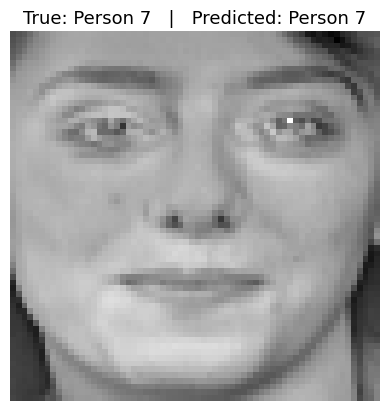

In [50]:
import matplotlib.pyplot as plt


# Pick a test sample to show off
i = 20  # change this to try different faces

# Get the image, true label, and prediction
sample_image = X_test_scaled[i]           # the test features (numpy array)
true_label   = y_test.iloc[i]             # the true person ID (using .iloc for positional access)
predicted    = pipeline.predict(sample_image.reshape(1, -1))[0] # predict on the sample_image features

# Reshape flat array → 64x64 image
image_2d = sample_image.reshape(64, 64)

# Display
plt.imshow(image_2d, cmap='gray')
plt.title(f"True: Person {true_label}   |   Predicted: Person {predicted}", fontsize=13)
plt.axis('off')
plt.show()

In [51]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print both results side by side
print("Logistic Regression — mean: 0.5823  std: 0.0466")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.5823  std: 0.0466
Random Forest       — mean: 0.9450  std: 0.0245

Logistic Regression wins!


In [56]:
# ============================================================
# ROUND 1 — CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Step 1 — Retrain best model (Logistic Regression) on train set
final_model = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200))]
)
final_model.fit(X_train_scaled, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test_scaled)

# Get unique class labels for target_names and display_labels
class_labels = sorted(y.unique().astype(str))

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=y.unique(), target_names=class_labels))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         4
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       0.00      0.00      0.00         0
          15       1.00      0.83      0.91         6
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         2
          18       1.00      1.00      1.00         2
          19       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
          20       1.00      1.00      1.00         1
          21       1.00      1.00      1.00         3
          22       1.00      1.00      1.00         2
          23       0.00      0.00      0.00         0
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

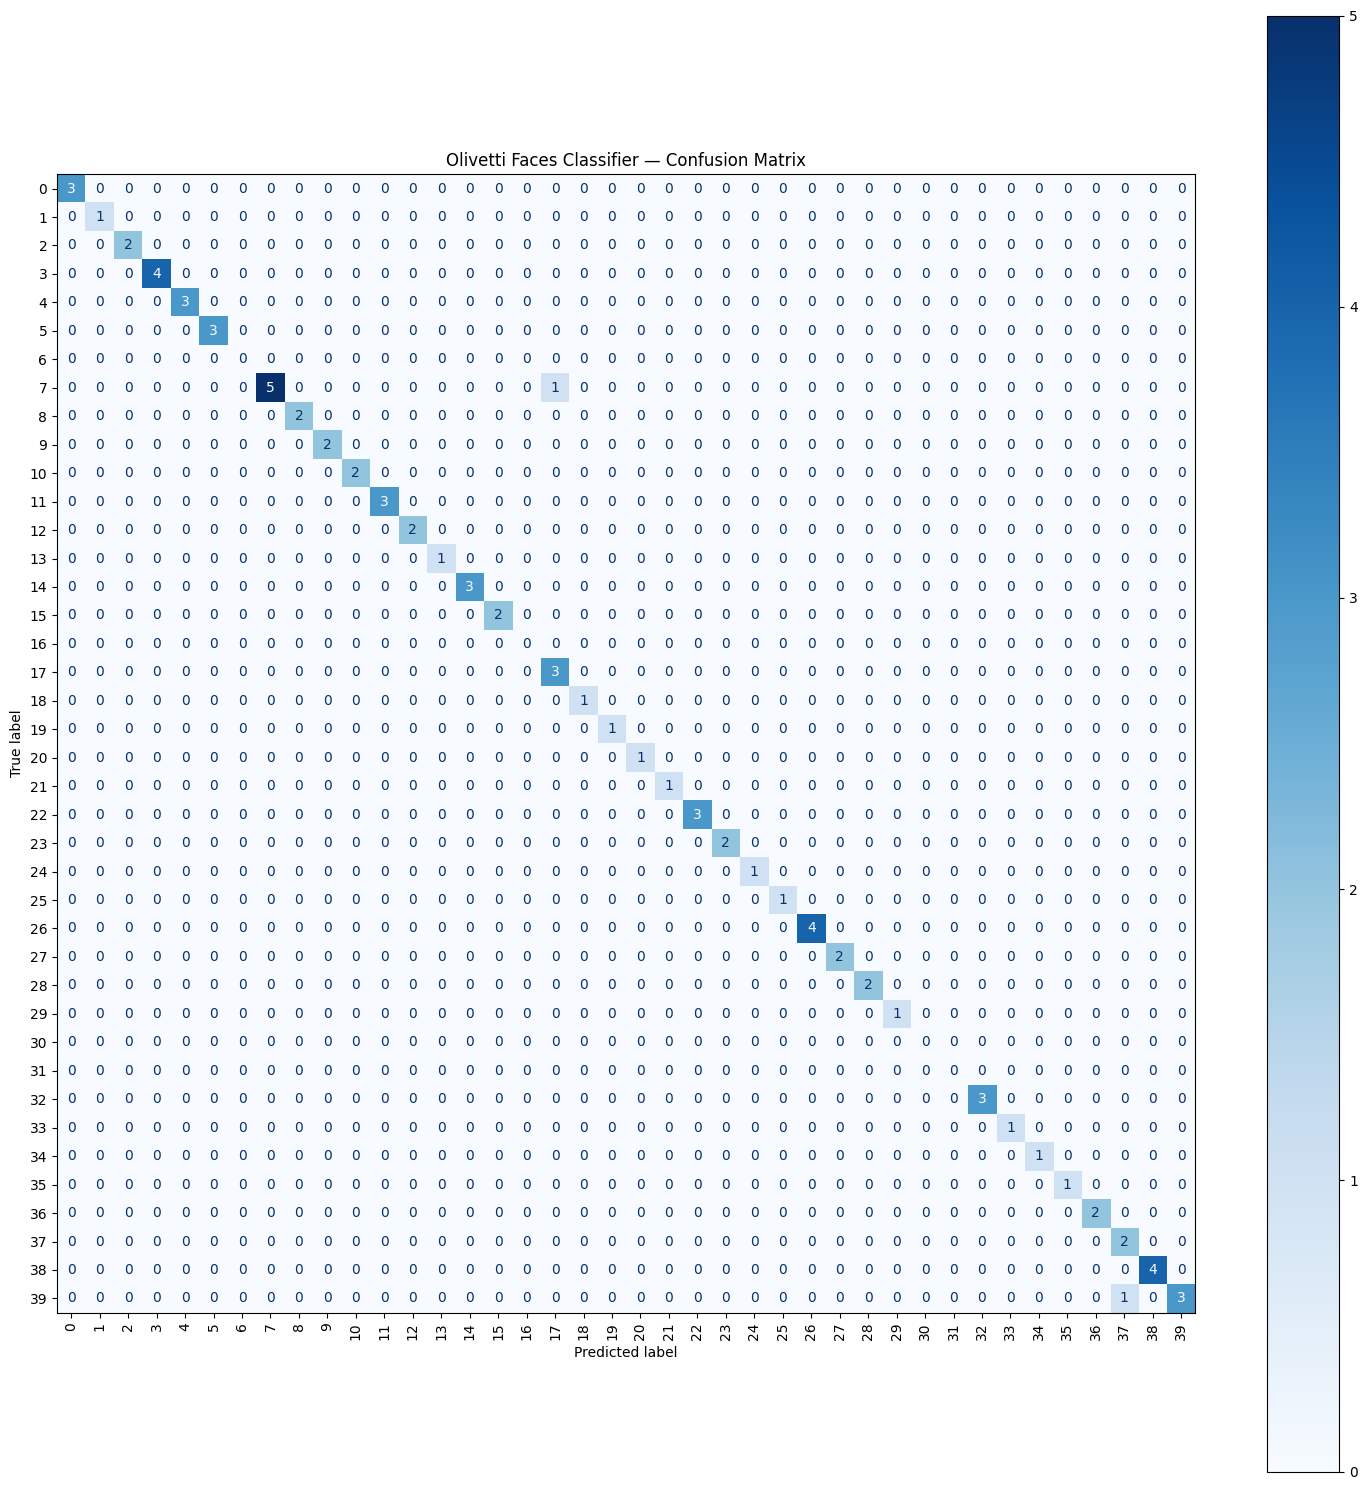

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure the confusion matrix is built for all 40 classes, matching display_labels
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Olivetti Faces Classifier — Confusion Matrix")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()